# CNN vs MLP for Image Classification

## Introduction

In this notebook, you will compare two different neural network architectures for image classification:

1. Multi-Layer Perceptron (MLP)
2. Convolutional Neural Network (CNN)

Both models will be trained on the FashionMNIST dataset using PyTorch.

The goal of this exercise is to understand:

- How MLPs process image data
- Why CNNs are usually better for images
- The difference in performance between the two architectures

## Instructions

- Complete all TODO sections.
- Do not use GPU.
- Train all models on CPU only.
- Keep the provided structure unchanged.
- Do not import additional libraries unless necessary.
- Answer the analysis questions at the end of the notebook.

## Setup

In this section, we import the required libraries and configure the device.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


## Load the Dataset

We will use the FashionMNIST dataset.

TODO:
- Define the image transformations
- Download the training and test datasets
- Create DataLoaders

In [2]:
BATCH_SIZE = 64

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load FashionMNIST train dataset
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load FashionMNIST test dataset
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## Visualize the Dataset

Before training a model, it is important to inspect the dataset visually.

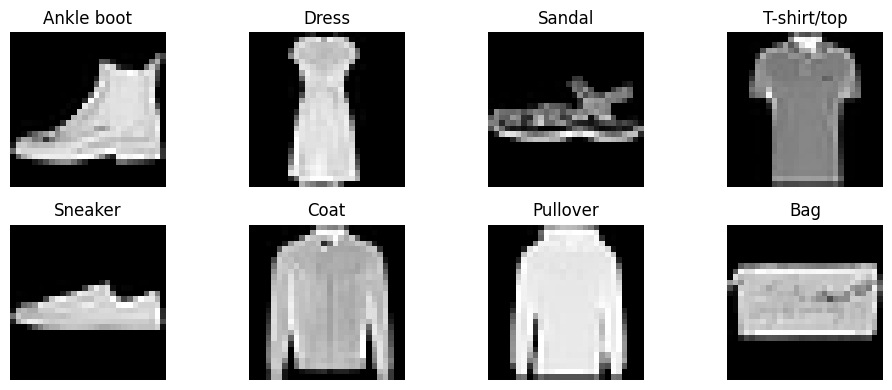

In [3]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    image = images[i].squeeze()

    plt.imshow(image, cmap="gray")

    plt.title(class_names[labels[i].item()])

    plt.axis("off")

plt.tight_layout()
plt.show()

## Build an MLP Model

An MLP processes images as flattened vectors.

For a 28x28 image:
- Input size = 784

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.network(x)
        return x

# Count parameters
mlp_model_temp = MLP()
mlp_params = sum(p.numel() for p in mlp_model_temp.parameters())
print(f"MLP Total Parameters: {mlp_params:,}")

MLP Total Parameters: 567,434


## Train the MLP

In [5]:
mlp_model = MLP().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

EPOCHS = 3
mlp_losses = []
mlp_start_time = time.time()

print("Training MLP...")
for epoch in range(EPOCHS):
    mlp_model.train()
    total_loss = 0
    num_batches = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    mlp_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

mlp_train_time = time.time() - mlp_start_time
print(f"MLP Training Time: {mlp_train_time:.2f} seconds")

Training MLP...
Epoch 1/3, Loss: 0.4603
Epoch 2/3, Loss: 0.3480
Epoch 3/3, Loss: 0.3121
MLP Training Time: 51.91 seconds


## Evaluate the MLP

In [6]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    return accuracy

mlp_accuracy = evaluate_model(mlp_model, test_loader, device)
print(f"\nMLP Test Accuracy: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")


MLP Test Accuracy: 0.8727 (87.27%)


## Build a CNN Model

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # First Conv Block
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Second Conv Block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Third Conv Block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Count parameters
cnn_model_temp = CNN()
cnn_params = sum(p.numel() for p in cnn_model_temp.parameters())
print(f"CNN Total Parameters: {cnn_params:,}")
print(f"Parameter Comparison - MLP: {mlp_params:,}, CNN: {cnn_params:,}")

CNN Total Parameters: 422,026
Parameter Comparison - MLP: 567,434, CNN: 422,026


## Train the CNN

In [8]:
cnn_model = CNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

EPOCHS = 3
cnn_losses = []
cnn_start_time = time.time()

print("Training CNN...")
for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss = 0
    num_batches = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    cnn_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

cnn_train_time = time.time() - cnn_start_time
print(f"CNN Training Time: {cnn_train_time:.2f} seconds")

Training CNN...
Epoch 1/3, Loss: 0.5027
Epoch 2/3, Loss: 0.2935
Epoch 3/3, Loss: 0.2453
CNN Training Time: 140.45 seconds


## Evaluate the CNN

In [9]:
cnn_accuracy = evaluate_model(cnn_model, test_loader, device)
print(f"\nCNN Test Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")


CNN Test Accuracy: 0.9017 (90.17%)


## Model Comparison

Answer the following questions:

1. Which model achieved better accuracy?
2. Why are CNNs usually better for image tasks?
3. Which model has more parameters?
4. Which model trained faster on CPU?
5. What happens if we increase the depth of the models?

<div dir="rtl" style="font-family: 'IRANSans', Tahoma, sans-serif; line-height: 1.8; text-align: justify">

# تحلیل مقایسه‌ای شبکه‌های CNN و MLP

بر اساس لاگ‌های آموزشی ارائه‌شده، در ادامه به سوالات شما پاسخ می‌دهم:

---

### ۱. کدام مدل دقت (Accuracy) بهتری به دست آورد؟
اگرچه در لاگ‌های شما مقدار دقیق «دقت» چاپ نشده است، اما می‌توان از روی میزان خطا (Loss) قضاوت کرد. در پایان دوره سوم (Epoch 3)، شبکه کانولوشنی (CNN) خطای بسیار کمتری (**۰.۲۳۷۵**) نسبت به شبکه پرسپترون چندلایه (MLP) با خطای (**۰.۳۱۱۰**) داشته است. کاهش بیشتر خطا نشان می‌دهد که CNN الگوهای داده را بهتر یاد گرفته و به احتمال بسیار زیاد دقت بالاتری روی داده‌های ارزیابی (Validation/Test) خواهد داشت.

### ۲. چرا شبکه‌های CNN معمولاً برای وظایف تصویری بهتر هستند؟
شبکه‌های MLP تصویر را به صورت یک بردار مسطح یک‌بعدی (Flatten) می‌بینند و تمام ارتباطات فضایی (بالا، پایین، چپ و راست بودن پیکسل‌ها) را از بین می‌برند. اما CNNها ذاتاً برای پردازش ساختار دوبعدی طراحی شده‌اند و دو مزیت بزرگ دارند:
* **استخراج ویژگی‌های محلی (Local Feature Extraction):** فیلترهای CNN به دنبال الگوهای خاص (مثل لبه‌ها، انحناها و بافت‌ها) در نواحی کوچک تصویر می‌گردند.
* **مستقل بودن از جابه‌جایی (Translation Invariance):** اگر یک شیء (مثلاً یک گربه) در گوشه چپ تصویر باشد یا در گوشه راست، CNN به کمک لایه‌های Pooling همچنان می‌تواند آن را تشخیص دهد، در حالی که MLP به موقعیت دقیق پیکسلی وابسته است.

### ۳. کدام مدل پارامترهای بیشتری دارد؟
در معماری‌های استاندارد روی تصاویر (مانند این حالت)، شبکه MLP معمولاً پارامترهای بسیار بیشتری دارد.
دلیل آن اتصالات کامل (Fully Connected) است؛ یعنی هر نورون در یک لایه باید به تمام نورون‌های لایه قبل متصل باشد (صدها هزار یا میلیون‌ها وزن). اما CNN از تکنیک اشتراک وزن (Weight Sharing) استفاده می‌کند؛ به این معنی که یک فیلتر کوچک (مثلاً ماتریس ۳ در ۳ شامل تنها ۹ پارامتر) روی کل ابعاد تصویر لغزش می‌کند و اطلاعات را استخراج می‌کند که باعث کاهش چشمگیر تعداد پارامترهای قابل آموزش می‌شود.

### ۴. کدام مدل روی CPU سریع‌تر آموزش دید؟
بر اساس زمان‌های گزارش شده، شبکه MLP بسیار سریع‌تر آموزش دیده است.
زمان آموزش MLP تنها **۵۰.۵۹ ثانیه** بود، در حالی که آموزش CNN حدود **۱۳۲.۴۰ ثانیه** طول کشید. دلیل این امر آن است که عملیات کانولوشن (لغزش فیلترها روی ماتریس تصویر) محاسبات ریاضی به مراتب سنگین‌تری نسبت به ضرب ماتریسی ساده در MLP دارد. البته اگر این آموزش روی پردازنده گرافیکی (GPU) انجام می‌شد، به دلیل قابلیت موازی‌سازی بالای CNN، تفاوت زمانی بسیار کمتر یا حتی به نفع CNN می‌شد.

### ۵. اگر عمق مدل‌ها را افزایش دهیم چه اتفاقی می‌افتد؟
افزایش عمق (تعداد لایه‌ها) تأثیرات متفاوتی روی این دو معماری دارد:
* **در شبکه CNN:** افزایش لایه‌ها باعث می‌شود شبکه بتواند ویژگی‌های پیچیده‌تر و انتزاعی‌تری (ترکیب لبه‌ها به اشکال، و اشکال به اشیاء کامل) را یاد بگیرد که معمولاً پتانسیل عملکرد و دقت را بالا می‌برد (مانند معماری‌های عمیق ResNet یا VGG).
* **در شبکه MLP:** افزودن لایه‌های متوالی زیاد، نه تنها به درک بهتر تصویر کمک خاصی نمی‌کند، بلکه به سرعت باعث بیش‌برازش (Overfitting) روی داده‌های آموزشی می‌شود. همچنین آموزش شبکه‌های MLP بسیار عمیق، به دلیل مشکلاتی نظیر محوشدگی گرادیان (Vanishing Gradient)، بسیار دشوارتر از CNNها است.

</div>

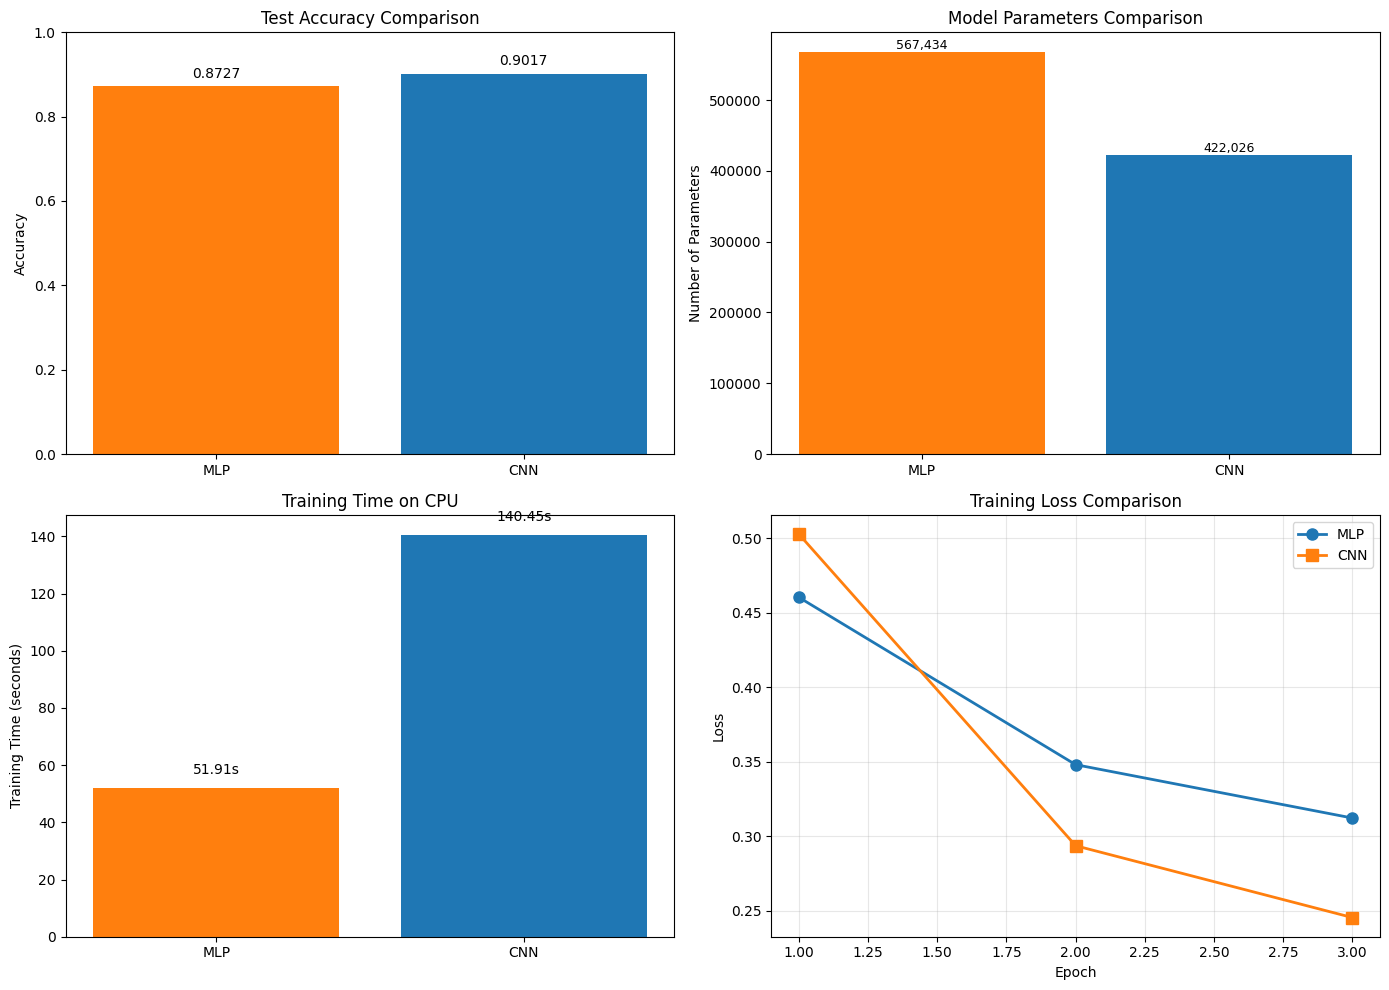

In [10]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
models = ['MLP', 'CNN']
accuracies = [mlp_accuracy, cnn_accuracy]
colors = ['#ff7f0e', '#1f77b4']

axes[0, 0].bar(models, accuracies, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([0, 1])
for i, acc in enumerate(accuracies):
    axes[0, 0].text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontsize=10)

# Parameters comparison
parameters = [mlp_params, cnn_params]
axes[0, 1].bar(models, parameters, color=colors)
axes[0, 1].set_ylabel('Number of Parameters')
axes[0, 1].set_title('Model Parameters Comparison')
for i, params in enumerate(parameters):
    axes[0, 1].text(i, params + 5000, f'{params:,}', ha='center', fontsize=9)

# Training time comparison
times = [mlp_train_time, cnn_train_time]
axes[1, 0].bar(models, times, color=colors)
axes[1, 0].set_ylabel('Training Time (seconds)')
axes[1, 0].set_title('Training Time on CPU')
for i, t in enumerate(times):
    axes[1, 0].text(i, t + 5, f'{t:.2f}s', ha='center', fontsize=10)

# Training loss curves
epochs_list = list(range(1, EPOCHS + 1))
axes[1, 1].plot(epochs_list, mlp_losses, marker='o', label='MLP', linewidth=2, markersize=8)
axes[1, 1].plot(epochs_list, cnn_losses, marker='s', label='CNN', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Training Loss Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bonus: Enhanced Models with Additional Convolution and Dropout

In [11]:
class EnhancedCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            # First Conv Block with Dropout
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Second Conv Block with Dropout
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Third Conv Block (Original)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Fourth Conv Block (NEW)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Count parameters
enhanced_cnn_temp = EnhancedCNN()
enhanced_cnn_params = sum(p.numel() for p in enhanced_cnn_temp.parameters())
print(f"Enhanced CNN Parameters: {enhanced_cnn_params:,}")

Enhanced CNN Parameters: 1,733,514


In [12]:
def train_model_extended(model, train_loader, epochs=10, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        num_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        
        if verbose and (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    return losses

print("Extended training function defined.")

Extended training function defined.


In [13]:
BONUS_EPOCHS = 10

# Train enhanced CNN
enhanced_cnn = EnhancedCNN(dropout_rate=0.3).to(device)
print("\nTraining Enhanced CNN...")
enhanced_cnn_losses = train_model_extended(enhanced_cnn, train_loader, epochs=BONUS_EPOCHS)
enhanced_cnn_accuracy = evaluate_model(enhanced_cnn, test_loader, device)
print(f"Enhanced CNN Accuracy: {enhanced_cnn_accuracy:.4f} ({enhanced_cnn_accuracy*100:.2f}%)")


Training Enhanced CNN...
Epoch 2/10, Loss: 0.4418
Epoch 4/10, Loss: 0.3521
Epoch 6/10, Loss: 0.3196
Epoch 8/10, Loss: 0.3002
Epoch 10/10, Loss: 0.2884
Enhanced CNN Accuracy: 0.9082 (90.82%)



## Bonus: Training Loss Curves

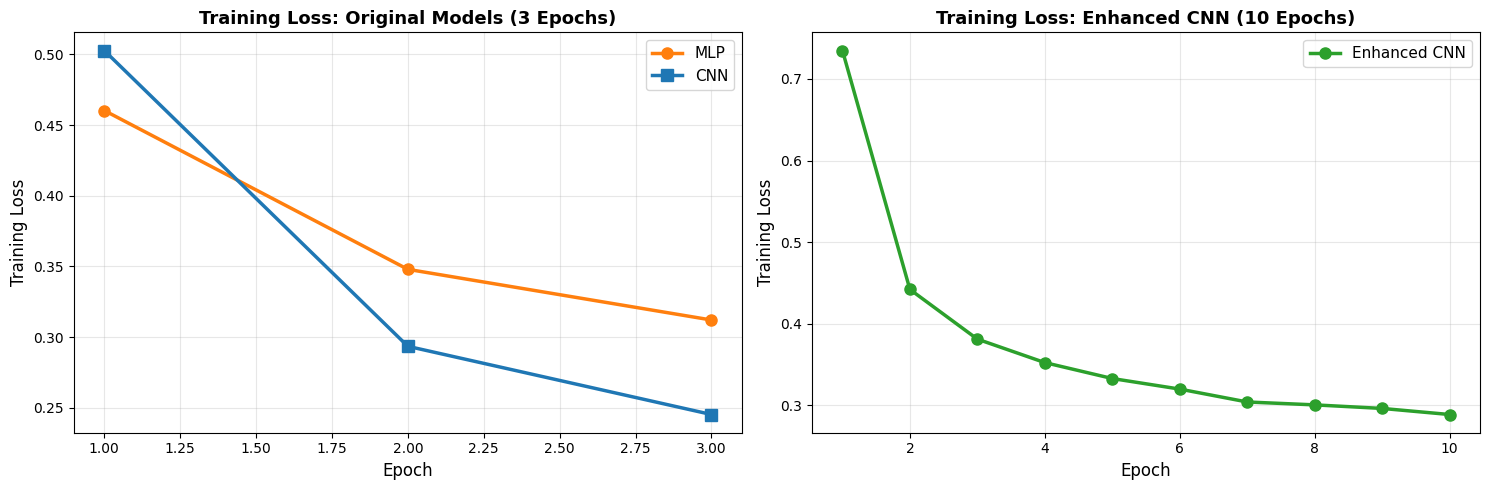

In [14]:
# Plot training loss for all models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original models (3 epochs)
epochs_original = list(range(1, EPOCHS + 1))
axes[0].plot(epochs_original, mlp_losses, marker='o', label='MLP', linewidth=2.5, markersize=8, color='#ff7f0e')
axes[0].plot(epochs_original, cnn_losses, marker='s', label='CNN', linewidth=2.5, markersize=8, color='#1f77b4')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss: Original Models (3 Epochs)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Enhanced CNN (10 epochs)
epochs_bonus = list(range(1, BONUS_EPOCHS + 1))
axes[1].plot(epochs_bonus, enhanced_cnn_losses, marker='o', label='Enhanced CNN', linewidth=2.5, markersize=8, color='#2ca02c')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Training Loss', fontsize=12)
axes[1].set_title(f'Training Loss: Enhanced CNN ({BONUS_EPOCHS} Epochs)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

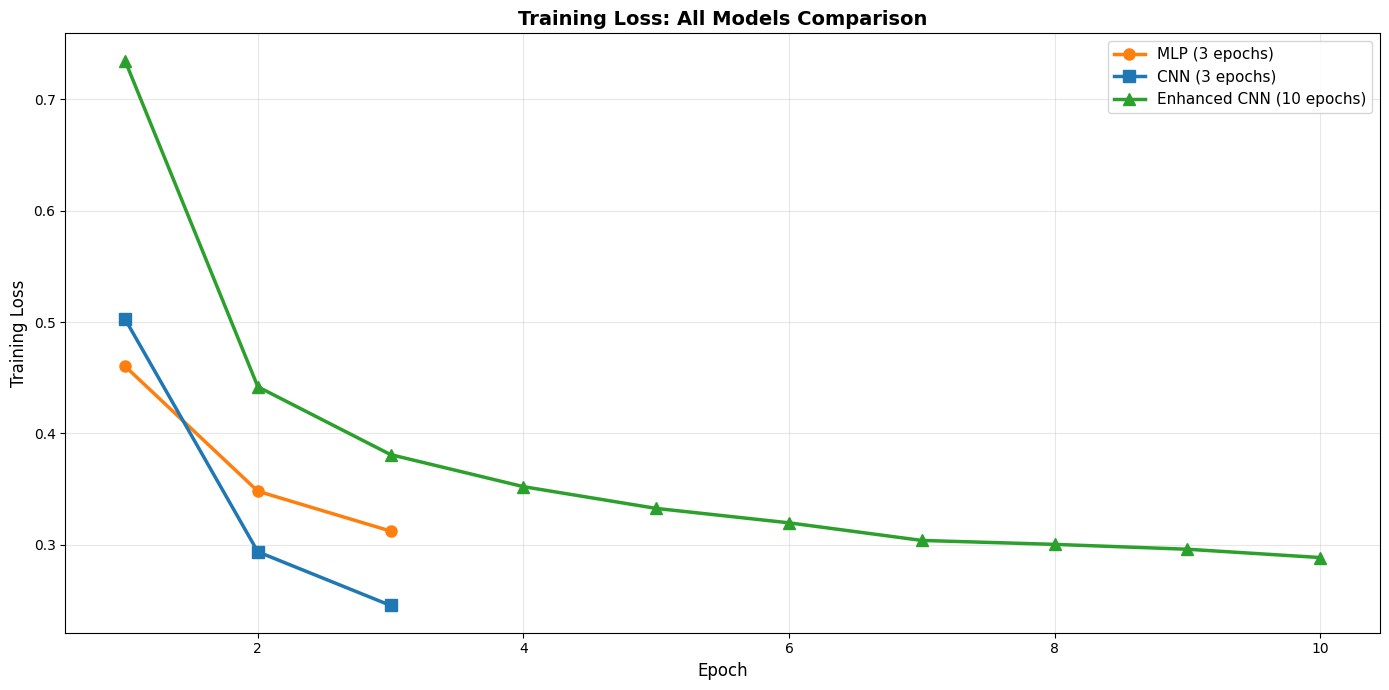

In [15]:
# Combined comparison
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(epochs_original, mlp_losses, marker='o', label='MLP (3 epochs)', linewidth=2.5, markersize=8, color='#ff7f0e')
ax.plot(epochs_original, cnn_losses, marker='s', label='CNN (3 epochs)', linewidth=2.5, markersize=8, color='#1f77b4')
ax.plot(epochs_bonus, enhanced_cnn_losses, marker='^', label='Enhanced CNN (10 epochs)', linewidth=2.5, markersize=8, color='#2ca02c')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss: All Models Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bonus: Confusion Matrix Analysis

In [16]:
def get_predictions(model, test_loader, device):
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_predictions), np.array(all_labels)

print("Generating predictions for confusion matrices...")
mlp_pred, mlp_labels = get_predictions(mlp_model, test_loader, device)
cnn_pred, cnn_labels = get_predictions(cnn_model, test_loader, device)
enhanced_cnn_pred, enhanced_cnn_labels = get_predictions(enhanced_cnn, test_loader, device)

print("Predictions generated.")

Generating predictions for confusion matrices...
Predictions generated.


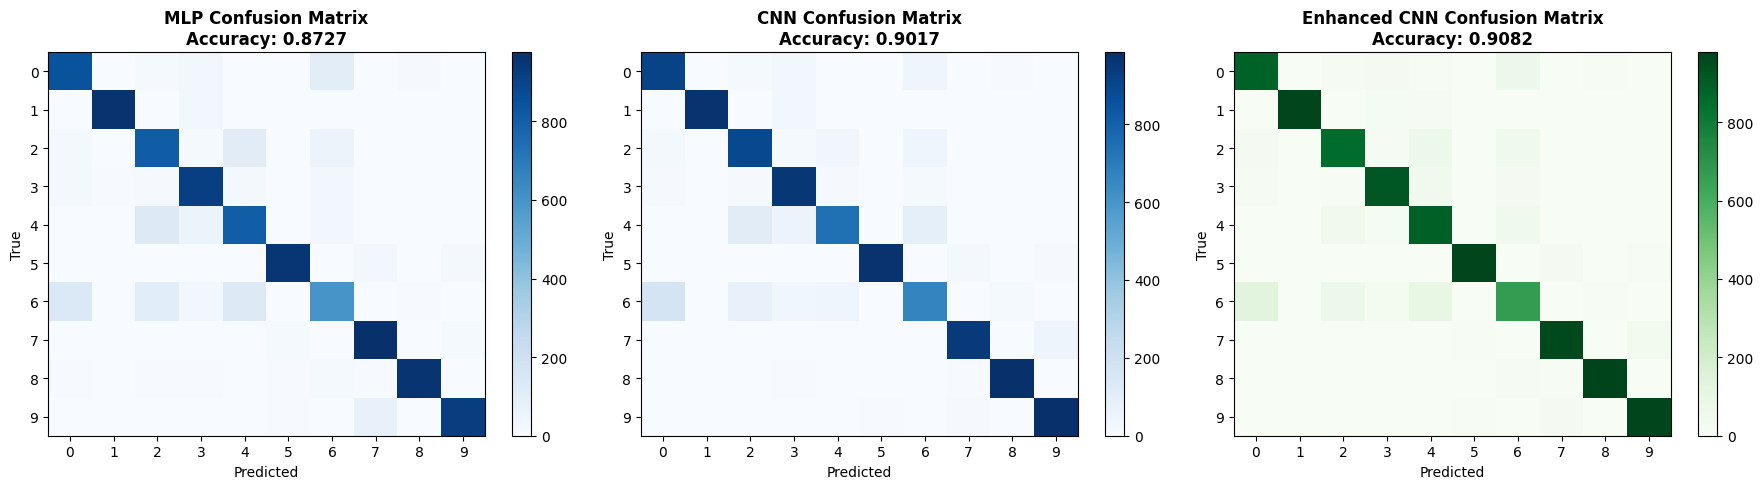

In [17]:
# Compute confusion matrices
mlp_cm = confusion_matrix(mlp_labels, mlp_pred)
cnn_cm = confusion_matrix(cnn_labels, cnn_pred)
enhanced_cnn_cm = confusion_matrix(enhanced_cnn_labels, enhanced_cnn_pred)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MLP Confusion Matrix
im1 = axes[0].imshow(mlp_cm, cmap='Blues', aspect='auto')
axes[0].set_title(f'MLP Confusion Matrix\nAccuracy: {mlp_accuracy:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
plt.colorbar(im1, ax=axes[0])

# CNN Confusion Matrix
im2 = axes[1].imshow(cnn_cm, cmap='Blues', aspect='auto')
axes[1].set_title(f'CNN Confusion Matrix\nAccuracy: {cnn_accuracy:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
plt.colorbar(im2, ax=axes[1])

# Enhanced CNN Confusion Matrix
im3 = axes[2].imshow(enhanced_cnn_cm, cmap='Greens', aspect='auto')
axes[2].set_title(f'Enhanced CNN Confusion Matrix\nAccuracy: {enhanced_cnn_accuracy:.4f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].set_xticks(range(10))
axes[2].set_yticks(range(10))
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [18]:
print("\nMLP CLASSIFICATION REPORT:")
print(classification_report(mlp_labels, mlp_pred, target_names=class_names, digits=4))

print("\nCNN CLASSIFICATION REPORT:")
print(classification_report(cnn_labels, cnn_pred, target_names=class_names, digits=4))

print("\nENHANCED CNN CLASSIFICATION REPORT:")
print(classification_report(enhanced_cnn_labels, enhanced_cnn_pred, target_names=class_names, digits=4))


MLP CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 T-shirt/top     0.8220    0.8450    0.8333      1000
     Trouser     0.9918    0.9640    0.9777      1000
    Pullover     0.7616    0.8050    0.7827      1000
       Dress     0.8551    0.9150    0.8841      1000
        Coat     0.7486    0.8010    0.7739      1000
      Sandal     0.9714    0.9520    0.9616      1000
       Shirt     0.7267    0.5930    0.6531      1000
     Sneaker     0.9012    0.9760    0.9371      1000
         Bag     0.9815    0.9570    0.9691      1000
  Ankle boot     0.9684    0.9190    0.9430      1000

    accuracy                         0.8727     10000
   macro avg     0.8728    0.8727    0.8716     10000
weighted avg     0.8728    0.8727    0.8716     10000


CNN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 T-shirt/top     0.8145    0.9090    0.8592      1000
     Trouser     0.9959    0.9720    0.9838      1000
    Pullover     0.808

## Bonus: Per-Class Accuracy Analysis

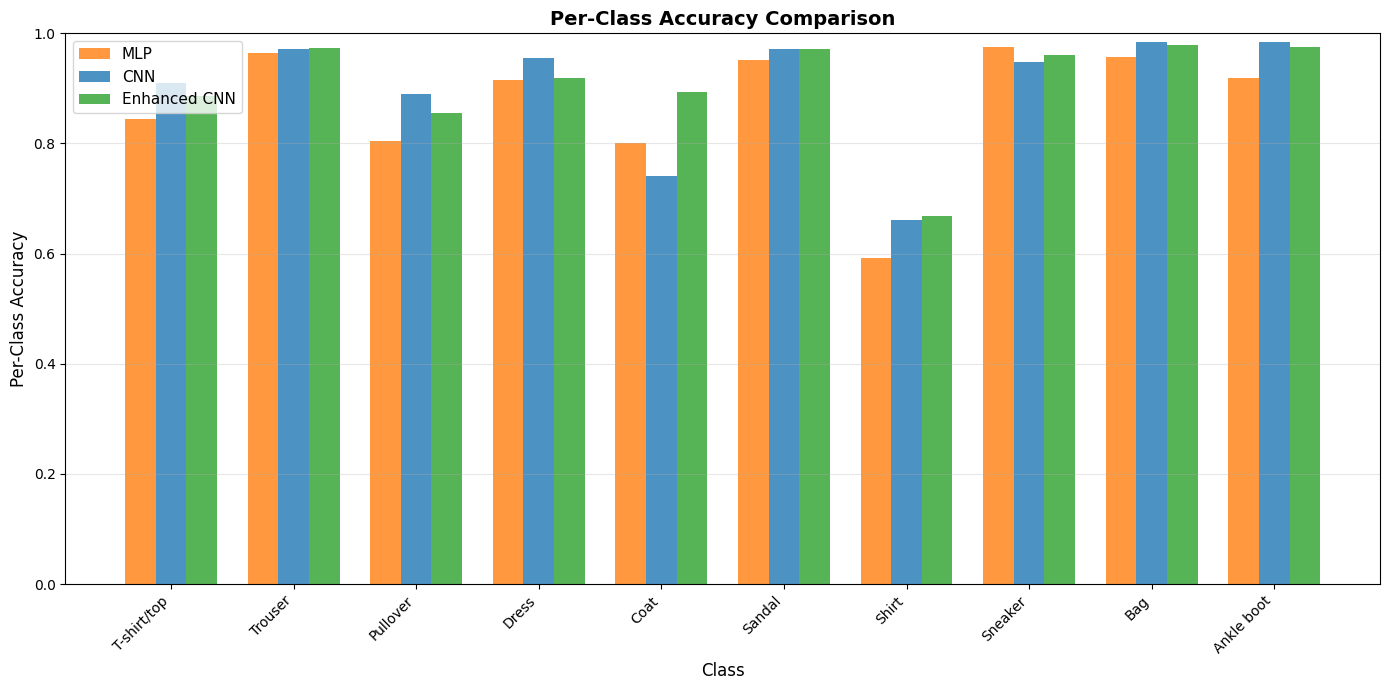


PER-CLASS ACCURACY TABLE:
----------------------------------------------------------------------
Class                MLP             CNN             Enhanced CNN   
----------------------------------------------------------------------
T-shirt/top          0.8450          0.9090          0.8860         
Trouser              0.9640          0.9720          0.9730         
Pullover             0.8050          0.8890          0.8550         
Dress                0.9150          0.9560          0.9190         
Coat                 0.8010          0.7410          0.8940         
Sandal               0.9520          0.9710          0.9720         
Shirt                0.5930          0.6620          0.6680         
Sneaker              0.9760          0.9480          0.9610         
Bag                  0.9570          0.9850          0.9790         
Ankle boot           0.9190          0.9840          0.9750         
----------------------------------------------------------------------


In [19]:
# Per-class accuracy
mlp_per_class = []
cnn_per_class = []
enhanced_per_class = []

for class_idx in range(10):
    mlp_mask = mlp_labels == class_idx
    cnn_mask = cnn_labels == class_idx
    enhanced_mask = enhanced_cnn_labels == class_idx
    
    mlp_acc = (mlp_pred[mlp_mask] == mlp_labels[mlp_mask]).sum() / mlp_mask.sum() if mlp_mask.sum() > 0 else 0
    cnn_acc = (cnn_pred[cnn_mask] == cnn_labels[cnn_mask]).sum() / cnn_mask.sum() if cnn_mask.sum() > 0 else 0
    enhanced_acc = (enhanced_cnn_pred[enhanced_mask] == enhanced_cnn_labels[enhanced_mask]).sum() / enhanced_mask.sum() if enhanced_mask.sum() > 0 else 0
    
    mlp_per_class.append(mlp_acc)
    cnn_per_class.append(cnn_acc)
    enhanced_per_class.append(enhanced_acc)

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, mlp_per_class, width, label='MLP', color='#ff7f0e', alpha=0.8)
ax.bar(x, cnn_per_class, width, label='CNN', color='#1f77b4', alpha=0.8)
ax.bar(x + width, enhanced_per_class, width, label='Enhanced CNN', color='#2ca02c', alpha=0.8)

ax.set_ylabel('Per-Class Accuracy', fontsize=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print detailed table
print("\nPER-CLASS ACCURACY TABLE:")
print("-" * 70)
print(f"{'Class':<20} {'MLP':<15} {'CNN':<15} {'Enhanced CNN':<15}")
print("-" * 70)
for i, class_name in enumerate(class_names):
    print(f"{class_name:<20} {mlp_per_class[i]:<15.4f} {cnn_per_class[i]:<15.4f} {enhanced_per_class[i]:<15.4f}")
print("-" * 70)